<a href="https://colab.research.google.com/github/Victor-Tung/CS171_news_classification/blob/main/CS171_news_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Data Investigation


In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Read the features file.
data = pd.read_csv('/content/drive/MyDrive/CS171/ag_train.csv',header=None,
                   names=['class', 'title', 'description'])
#first 30 lines are all class index 3, data set is well balanced
print(data['class'].value_counts().sort_index())
print('-----------------------------------')
data.tail(5)


class
1              1900
2              1900
3              1900
4              1900
Class Index       1
Name: count, dtype: int64
-----------------------------------


,class,title,description
7596,1,Around the world,"Ukrainian presidential candidate Viktor Yushchenko was poisoned with the most harmful known dioxin, which is contained in Agent Orange, a scientist who analyzed his blood said Friday."
7597,2,Void is filled with Clement,"With the supply of attractive pitching options dwindling daily -- they lost Pedro Martinez to the Mets, missed on Tim Hudson, and are resigned to Randy Johnson becoming a Yankee -- the Red Sox struck again last night, coming to terms with free agent Matt Clement on a three-year deal that will pay the righthander in the neighborhood of \$25 ..."
7598,2,Martinez leaves bitter,"Like Roger Clemens did almost exactly eight years earlier, Pedro Martinez has left the Red Sox apparently bitter about the way he was treated by management."
7599,3,5 of arthritis patients in Singapore take Bextra or Celebrex &lt;b&gt;...&lt;/b&gt;,SINGAPORE : Doctors in the United States have warned that painkillers Bextra and Celebrex may be linked to major cardiovascular problems and should not be prescribed.
7600,3,EBay gets into rentals,"EBay plans to buy the apartment and home rental service Rent.com for \$415 million, adding to its already exhaustive breadth of offerings."


In [3]:
data.shape

(7601, 3)

In [4]:
data.columns

Index(['class', 'title', 'description'], dtype='object')

In [5]:
data.dtypes

,0
class,object
title,object
description,object


# Data Preprocessing and Cleaning


In [6]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)        # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()          # collapse extra whitespace
    text = ' '.join([w for w in text.split() if w not in stop_words])  # remove stopwords
    return text

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
data['title_clean'] = data['title'].apply(clean_text)
data['description_clean'] = data['description'].apply(clean_text)
data['text'] = data['title_clean'] + ' ' + data['description_clean']

In [8]:
# testing clean function
test_val = 5000
print("BEFORE:", data['title'].iloc[test_val])
print("AFTER: ", data['title_clean'].iloc[test_val])
print()
print("BEFORE:", data['description'].iloc[test_val])
print("AFTER: ", data['description_clean'].iloc[test_val])
data.head(5)

BEFORE: Profit Plunges at International Game Tech
AFTER:  profit plunges international game tech

BEFORE: International Game Technology, the world #39;s biggest maker of slot machines, Tuesday said said profit for its latest quarter fell 50 percent from a year ago due to a charge for early redemption of debt and a tax adjustment.
AFTER:  international game technology world 39 biggest maker slot machines tuesday said said profit latest quarter fell 50 percent year ago due charge early redemption debt tax adjustment


,class,title,description,title_clean,description_clean,text
0,Class Index,Title,Description,title,description,title description
1,3,Fears for T N pension after talks,Unions representing workers at Turner Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul.,fears n pension talks,unions representing workers turner newall say disappointed talks stricken parent firm federal mogul,fears n pension talks unions representing workers turner newall say disappointed talks stricken parent firm federal mogul
2,4,The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com),"SPACE.com - TORONTO, Canada -- A second\team of rocketeers competing for the #36;10 million Ansari X Prize, a contest for\privately funded suborbital space flight, has officially announced the first\launch date for its manned rocket.",race second private team sets launch date human spaceflight space com,space com toronto canada second team rocketeers competing 36 10 million ansari x prize contest privately funded suborbital space flight officially announced first launch date manned rocket,race second private team sets launch date human spaceflight space com space com toronto canada second team rocketeers competing 36 10 million ansari x prize contest privately funded suborbital space flight officially announced first launch date manned rocket
3,4,Ky. Company Wins Grant to Study Peptides (AP),"AP - A company founded by a chemistry researcher at the University of Louisville won a grant to develop a method of producing better peptides, which are short chains of amino acids, the building blocks of proteins.",ky company wins grant study peptides ap,ap company founded chemistry researcher university louisville grant develop method producing better peptides short chains amino acids building blocks proteins,ky company wins grant study peptides ap ap company founded chemistry researcher university louisville grant develop method producing better peptides short chains amino acids building blocks proteins
4,4,Prediction Unit Helps Forecast Wildfires (AP),"AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur of colorful maps, figures and endless charts, but already he knows what the day will bring. Lightning will strike in places he expects. Winds will pick up, moist places will dry and flames will roar.",prediction unit helps forecast wildfires ap,ap barely dawn mike fitzpatrick starts shift blur colorful maps figures endless charts already knows day bring lightning strike places expects winds pick moist places dry flames roar,prediction unit helps forecast wildfires ap ap barely dawn mike fitzpatrick starts shift blur colorful maps figures endless charts already knows day bring lightning strike places expects winds pick moist places dry flames roar


# Building/Training Custom CNN


In [9]:
data = data[data["class"] != "Class Index"].copy()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

texts = data["text"].astype(str).values
labels = data["class"].values

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)
y = to_categorical(y)

# Split
X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    texts, y, test_size=0.2, random_state=42, stratify=labels
)

# Tokenize
max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_texts)

X_train_seq = tokenizer.texts_to_sequences(X_train_texts)
X_test_seq = tokenizer.texts_to_sequences(X_test_texts)

# Pad
max_len = 100
X_train = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.5164 - loss: 1.1757 - val_accuracy: 0.8429 - val_loss: 0.5778
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.8684 - loss: 0.4181 - val_accuracy: 0.8717 - val_loss: 0.4041
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9562 - loss: 0.1605 - val_accuracy: 0.8635 - val_loss: 0.4322
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.9870 - loss: 0.0580 - val_accuracy: 0.8635 - val_loss: 0.4806
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9959 - loss: 0.0241 - val_accuracy: 0.8717 - val_loss: 0.5374
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.9984 - loss: 0.0126 - val_accuracy: 0.8734 - val_loss: 0.5782
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.9988 - loss: 0.0075 - val_accuracy: 0.8668 - val_loss: 0.6347
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9990 - loss: 0.0077 - val_ac

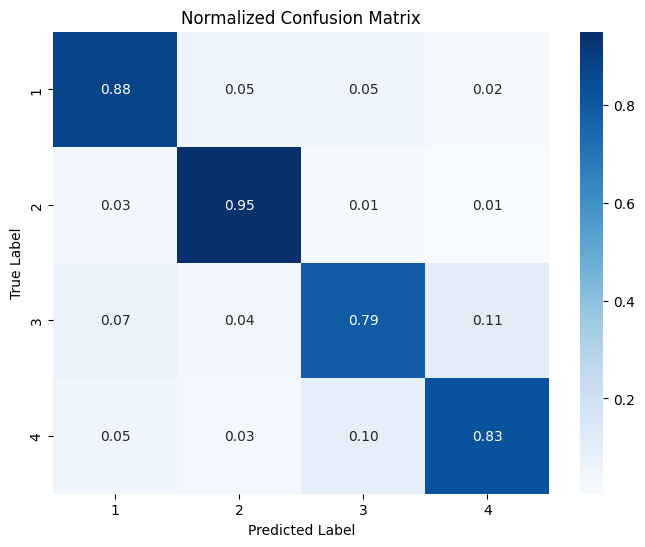

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

embedding_dim = 128
num_classes = y.shape[1] # Determine number of classes from the shape of y

model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim),

    Conv1D(filters=128, kernel_size=3, activation="relu"),
    GlobalMaxPooling1D(),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Train
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


# Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

predicted_labels = label_encoder.inverse_transform(y_pred)
true_labels = label_encoder.inverse_transform(y_true)

print("\nClassification Report:\n")
print(classification_report(true_labels, predicted_labels))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n")
print(cm)

cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.show()




# Fine-tuning DistilBERT

# Compare/Constrast Results